# 🥦 Klasifikasi Kesegaran Sayur & Buah
### Transfer Learning MobileNetV2 — Feature Extraction

**Dataset:** sayur_buah_gambar  
**Total gambar:** 68.752 | **Total kelas:** 30

**Struktur dataset:**
```
sayur_buah_gambar/
├── buah/
│   ├── unripe/   ← apple_unripe/, banana_unripe/, ...
│   ├── ripe/
│   ├── overripe/
│   └── rotten/
└── sayur/
    ├── fresh/   ← cabe_fresh/, tomat_fresh/, ...
    └── rotten/
```

**Keputusan desain:**
| Aspek | Keputusan | Alasan |
|---|---|---|
| Model | MobileNetV2 | Ringan, cocok untuk mobile |
| Fase training | 1 fase (Feature Extraction) | Hemat RAM 12 GB; dataset sudah cukup besar |
| Imbalance | Undersampling + Class weight | Hemat RAM dan balance |
| Augmentasi | On-the-fly di custom Sequence | Hemat disk, variasi lebih besar per epoch |
| Out-of-scope | Confidence threshold + entropy | Menolak gambar di luar dataset |

**Label final model:** `nama_item` → `jenis_item` → `kondisi_fisik`  
Contoh output: `{'nama_item': 'apple', 'jenis_item': 'Buah', 'kondisi_fisik': 'Matang', 'confidence': '94.3%'}`

## 1. Setup & Instalasi Library

In [ ]:
# Uncomment jika belum terinstall
# !pip install tensorflow matplotlib seaborn scikit-learn pillow

import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import shutil, zipfile
from google.colab import drive

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import Sequence, to_categorical

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow  :", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

TensorFlow  : 2.20.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Konfigurasi

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Copy dataset di Drive ke lokal
ZIP_PATH   = "/content/drive/MyDrive/sayur_buah_gambar.zip"
LOCAL_DIR  = "/content/sayur_buah_gambar"

if not os.path.exists(LOCAL_DIR):
    print("Menyalin zip dari Drive ke lokal...")
    shutil.copy(ZIP_PATH, "/content/sayur_buah_gambar.zip")   # ~1-2 menit
    print("Mengekstrak...")
    with zipfile.ZipFile("/content/sayur_buah_gambar.zip") as z:
        z.extractall("/content/")
    print("Selesai!")
else:
    print("Dataset sudah ada di lokal, skip copy.")

Menyalin zip dari Drive ke lokal...
Mengekstrak...
Selesai!


In [ ]:
# Sesuaikan path ini
DATASET_DIR = "/content/sayur_buah_gambar"

IMG_SIZE   = 224
BATCH_SIZE = 32
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15

EPOCHS = 50
LR     = 1e-3
MAX_PER_CLASS = 1500

CONFIDENCE_THRESHOLD = 0.60
ENTROPY_THRESHOLD    = 1.134

# Mapping folder kondisi → Bahasa Indonesia
KONDISI_MAP = {
    ('buah', 'unripe')   : ('Buah', 'Mentah'),
    ('buah', 'ripe')     : ('Buah', 'Matang'),
    ('buah', 'overripe') : ('Buah', 'Terlalu Matang'),
    ('buah', 'rotten')   : ('Buah', 'Busuk'),
    ('sayur', 'fresh')   : ('Sayur', 'Segar'),
    ('sayur', 'rotten')  : ('Sayur', 'Busuk'),
}

# Mapping folder item -> Bahasa Indonesia
NAMA_ITEM_MAP = {
    'apple'      : 'Apel',
    'banana'     : 'Pisang',
    'mango'      : 'Mangga',
    'orange'     : 'Jeruk',
    'carrot'     : 'Wortel',
    'potato'     : 'Kentang',
    'cabe'       : 'Cabai',
    'grape'      : 'Anggur',
    'timun'      : 'Mentimun',
    'tomat'      : 'Tomat',
}

print("Mapping Label:")
for (jenis, folder), (jenis_std, kondisi) in KONDISI_MAP.items():
    print(f"  {jenis:<6}/{folder:<10} → {jenis_std}, {kondisi}")
print("\nMapping Nama Item:")
for eng, indo in NAMA_ITEM_MAP.items():
    print(f"  {eng:<15} → {indo}")
print(f"\nMAX_PER_CLASS : {MAX_PER_CLASS}")

Mapping Label:
  buah  /unripe     → Buah, Mentah
  buah  /ripe       → Buah, Matang
  buah  /overripe   → Buah, Terlalu Matang
  buah  /rotten     → Buah, Busuk
  sayur /fresh      → Sayur, Segar
  sayur /rotten     → Sayur, Busuk

Mapping Nama Item:
  apple           → Apel
  banana          → Pisang
  mango           → Mangga
  orange          → Jeruk
  carrot          → Wortel
  potato          → Kentang
  cabe            → Cabai
  grape           → Anggur
  timun           → Mentimun
  tomat           → Tomat

MAX_PER_CLASS : 1500


## 3. Scan Dataset & Buat Label Standar

In [ ]:
dataset_path = Path(DATASET_DIR)
extensions   = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

all_paths    = []
all_labels   = []
all_meta     = []
label_counts = defaultdict(int)
label_skipped = defaultdict(int)

for jenis_dir in ['buah', 'sayur']:
    jenis_path = dataset_path / jenis_dir
    if not jenis_path.exists():
        print(f"[WARN] Folder tidak ditemukan: {jenis_path}")
        continue

    for kondisi_folder in sorted(jenis_path.iterdir()):
        if not kondisi_folder.is_dir():
            continue
        kondisi_key = kondisi_folder.name.lower()
        map_key = (jenis_dir, kondisi_key)

        if map_key not in KONDISI_MAP:
            print(f"[SKIP] Tidak ada mapping untuk: {jenis_dir}/{kondisi_key}")
            continue

        jenis_std, kondisi_std = KONDISI_MAP[map_key]

        for item_folder in sorted(kondisi_folder.iterdir()):
            if not item_folder.is_dir():
                continue

            raw_name  = item_folder.name.lower()
            nama_item = raw_name
            for suffix in ['_unripe', '_ripe', '_overripe', '_rotten', '_fresh']:
                nama_item = nama_item.replace(suffix, '')

            # Terjemahkan nama item ke bahasa Indonesia
            nama_item_indo = NAMA_ITEM_MAP.get(nama_item, nama_item.title())

            imgs  = [f for f in item_folder.iterdir() if f.suffix in extensions]

            # Kembali menggunakan pemisah aman ||
            label = f"{nama_item_indo}||{jenis_std}||{kondisi_std}"

            if len(imgs) > MAX_PER_CLASS:
                random.shuffle(imgs)
                label_skipped[label] += len(imgs) - MAX_PER_CLASS
                imgs = imgs[:MAX_PER_CLASS]

            for img_path in imgs:
                all_paths.append(str(img_path))
                all_labels.append(label)
                all_meta.append({
                    'path'         : str(img_path),
                    'nama_item'    : nama_item_indo,
                    'jenis_item'   : jenis_std,
                    'kondisi_fisik': kondisi_std,
                    'label'        : label
                })
                label_counts[label] += 1

print(f"Total gambar dipakai : {len(all_paths):,}")
print(f"Total label          : {len(label_counts)}")

if label_skipped:
    skipped_total = sum(label_skipped.values())
    print(f"\nGambar di-cap (diskip): {skipped_total:,}")
    print(f"{'Label':<40} {'Dipakai':>8} {'Diskip':>8}")
    print("-" * 60)
    for lbl in sorted(label_skipped):
        parts = lbl.split('||')
        name  = f"{parts[0]}||{parts[2]}"
        print(f"  {name:<38} {label_counts[lbl]:>8,} {label_skipped[lbl]:>8,}")

print()
df_meta = pd.DataFrame(all_meta)
print("Label unik yang ditemukan:")
for lbl, cnt in sorted(label_counts.items()):
    parts = lbl.split('||')
    capped = ' ← capped' if label_skipped.get(lbl, 0) > 0 else ''
    print(f"  {parts[0]:<15} | {parts[1]:<6} | {parts[2]:<15} : {cnt:>5} gambar{capped}")

Total gambar dipakai : 24,786
Total label          : 30

Gambar di-cap (diskip): 44,510
Label                                     Dipakai   Diskip
------------------------------------------------------------
  Apel||Busuk                               1,500    2,932
  Apel||Matang                              1,500    1,931
  Jeruk||Busuk                              1,500    1,792
  Jeruk||Matang                             1,500    9,331
  Pisang||Busuk                             1,500    2,543
  Pisang||Matang                            1,500    1,972
  Tomat||Busuk                              1,500    2,512
  Tomat||Segar                              1,500   12,181
  Wortel||Busuk                             1,500      918
  Wortel||Segar                             1,500    8,398

Label unik yang ditemukan:
  Anggur          | Buah   | Busuk           :   609 gambar
  Anggur          | Buah   | Matang          :   111 gambar
  Anggur          | Buah   | Mentah          :   226 g

In [ ]:
CLASS_NAMES = sorted(label_counts.keys())
NUM_CLASSES = len(CLASS_NAMES)

label2idx = {name: idx for idx, name in enumerate(CLASS_NAMES)}
idx2label = {idx: name for name, idx in label2idx.items()}

print(f"Total kelas : {NUM_CLASSES}")
print()
print(f"{'Idx':<4} {'Label'}")
print("-" * 55)
for idx, name in enumerate(CLASS_NAMES):
    parts = name.split('||')
    print(f"[{idx:>2}] {parts[0]:<15} | {parts[1]:<6} | {parts[2]}")

Total kelas : 30

Idx  Label
-------------------------------------------------------
[ 0] Anggur          | Buah   | Busuk
[ 1] Anggur          | Buah   | Matang
[ 2] Anggur          | Buah   | Mentah
[ 3] Anggur          | Buah   | Terlalu Matang
[ 4] Apel            | Buah   | Busuk
[ 5] Apel            | Buah   | Matang
[ 6] Apel            | Buah   | Mentah
[ 7] Apel            | Buah   | Terlalu Matang
[ 8] Cabai           | Sayur  | Busuk
[ 9] Cabai           | Sayur  | Segar
[10] Jeruk           | Buah   | Busuk
[11] Jeruk           | Buah   | Matang
[12] Jeruk           | Buah   | Mentah
[13] Jeruk           | Buah   | Terlalu Matang
[14] Kentang         | Sayur  | Busuk
[15] Kentang         | Sayur  | Segar
[16] Mangga          | Buah   | Busuk
[17] Mangga          | Buah   | Matang
[18] Mangga          | Buah   | Mentah
[19] Mangga          | Buah   | Terlalu Matang
[20] Mentimun        | Sayur  | Busuk
[21] Mentimun        | Sayur  | Segar
[22] Pisang          | Buah   | Bus

## 4. Eksplorasi & Visualisasi Dataset

In [ ]:
df_summary = (df_meta
              .groupby(['jenis_item', 'kondisi_fisik'])
              .size()
              .reset_index(name='jumlah'))
print(df_summary.to_string(index=False))
print(f"\nTotal: {df_summary['jumlah'].sum():,} gambar")

# Rasio imbalance
sorted_labels = sorted(label_counts.keys())
counts = [label_counts[k] for k in sorted_labels]
print(f"Kelas terbesar : {max(counts):,} ({sorted_labels[np.argmax(counts)]})")
print(f"Kelas terkecil : {min(counts):,} ({sorted_labels[np.argmin(counts)]})")

jenis_item  kondisi_fisik  jumlah
      Buah          Busuk    5702
      Buah         Matang    5216
      Buah         Mentah    1343
      Buah Terlalu Matang    1246
     Sayur          Busuk    5714
     Sayur          Segar    5565

Total: 24,786 gambar
Kelas terbesar : 1,500 (Apel||Buah||Busuk)
Kelas terkecil : 111 (Anggur||Buah||Matang)


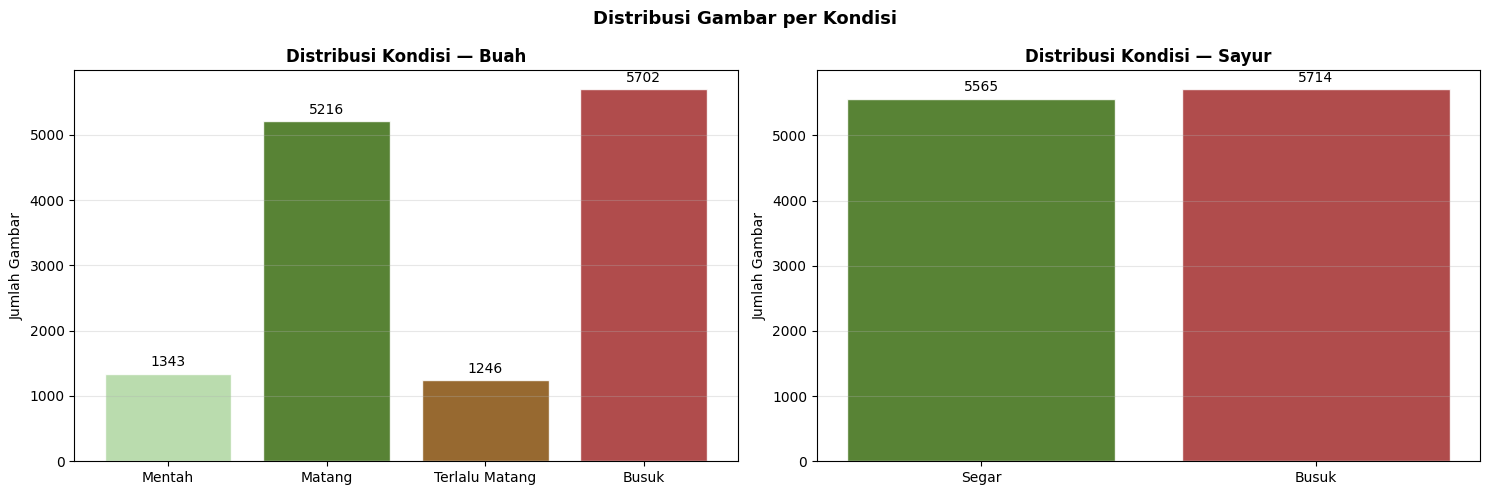

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df_buah  = df_meta[df_meta['jenis_item'] == 'Buah']
order_buah = ['Mentah', 'Matang', 'Terlalu Matang', 'Busuk']
counts_buah = [len(df_buah[df_buah['kondisi_fisik'] == k]) for k in order_buah]
bars = axes[0].bar(order_buah, counts_buah,
                   color=['#aed6a0','#3b6d11','#854f0b','#a32d2d'],
                   alpha=0.85, edgecolor='white')
axes[0].bar_label(bars, padding=3, fmt='%d')
axes[0].set_title('Distribusi Kondisi — Buah', fontweight='bold')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].grid(axis='y', alpha=0.3)

df_sayur = df_meta[df_meta['jenis_item'] == 'Sayur']
order_sayur = ['Segar', 'Busuk']
counts_sayur = [len(df_sayur[df_sayur['kondisi_fisik'] == k]) for k in order_sayur]
bars2 = axes[1].bar(order_sayur, counts_sayur,
                    color=['#3b6d11','#a32d2d'],
                    alpha=0.85, edgecolor='white')
axes[1].bar_label(bars2, padding=3, fmt='%d')
axes[1].set_title('Distribusi Kondisi — Sayur', fontweight='bold')
axes[1].set_ylabel('Jumlah Gambar')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Distribusi Gambar per Kondisi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distribusi_kondisi.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Persiapan Data — Split + Class Weight + Augmentasi

**Augmentasi on-the-fly:**  
Augmentasi diintegrasikan langsung menggunakan `Keras Preprocessing Layers` (atau melalui pipeline tf.data), sehingga komputasi berjalan secara dinamis di memori, sangat menghemat penyimpanan disk, dan secara otomatis memberikan variasi gambar yang unik pada setiap putaran epoch.

In [ ]:
paths  = np.array(all_paths)
labels = np.array(all_labels)

# Stratified split 70 / 15 / 15
X_temp, X_test, y_temp, y_test = train_test_split(
    paths, labels,
    test_size=TEST_SPLIT,
    stratify=labels,
    random_state=SEED
)
val_ratio = VAL_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_ratio,
    stratify=y_temp,
    random_state=SEED
)

y_train_idx = np.array([label2idx[l] for l in y_train])
y_val_idx   = np.array([label2idx[l] for l in y_val])
y_test_idx  = np.array([label2idx[l] for l in y_test])

print(f"Train : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

Train : 17,350
Val   : 3,718
Test  : 3,718


In [ ]:
# Hitung Class Weight
# compute_class_weight menghitung bobot invers-frekuensi:
# kelas dengan sedikit sampel → bobot besar → loss lebih tinggi jika salah
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train_idx
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}

print("Class weight (sampel):")
# Tampilkan 10 kelas dengan bobot tertinggi (kelas minoritas)
sorted_cw = sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)
for idx, w in sorted_cw[:10]:
    lbl = CLASS_NAMES[idx].split('||')
    print(f"  [{idx:>2}] {lbl[0]:<15} | {lbl[2]:<16} → weight: {w:.3f}")
print(f"  ... (total {NUM_CLASSES} kelas)")

Class weight (sampel):
  [ 1] Anggur          | Matang           → weight: 7.511
  [19] Mangga          | Terlalu Matang   → weight: 7.415
  [ 3] Anggur          | Terlalu Matang   → weight: 6.648
  [18] Mangga          | Mentah           → weight: 4.627
  [12] Jeruk           | Mentah           → weight: 3.934
  [13] Jeruk           | Terlalu Matang   → weight: 3.908
  [ 2] Anggur          | Mentah           → weight: 3.660
  [ 6] Apel            | Mentah           → weight: 3.362
  [ 9] Cabai           | Segar            → weight: 2.665
  [ 8] Cabai           | Busuk            → weight: 2.629
  ... (total 30 kelas)


In [ ]:
# tf.data pipeline

AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    """Baca & resize gambar, normalisasi ke [0,1]."""
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment_fn(img, label):
    """Augmentasi on-the-fly (hanya untuk training)."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_crop(img, size=[int(IMG_SIZE * 0.9), int(IMG_SIZE * 0.9), 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.image.random_saturation(img, lower=0.85, upper=1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def make_dataset(paths, labels_idx, augment=False, shuffle=False):
    """
    Buat tf.data.Dataset dengan:
    - parallel map  : baca banyak gambar sekaligus di CPU
    - prefetch      : siapkan batch berikutnya saat GPU masih proses batch sekarang
    - shuffle buffer: acak data setiap epoch
    """
    ds = tf.data.Dataset.from_tensor_slices(
        (paths, labels_idx.astype('int32'))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(X_train, y_train_idx, augment=True,  shuffle=True)
val_ds   = make_dataset(X_val,   y_val_idx,   augment=False, shuffle=False)
test_ds  = make_dataset(X_test,  y_test_idx,  augment=False, shuffle=False)

print(f"Train batches : {len(train_ds)}")
print(f"Val   batches : {len(val_ds)}")
print(f"Test  batches : {len(test_ds)}")


Train batches : 543
Val   batches : 117
Test  batches : 117


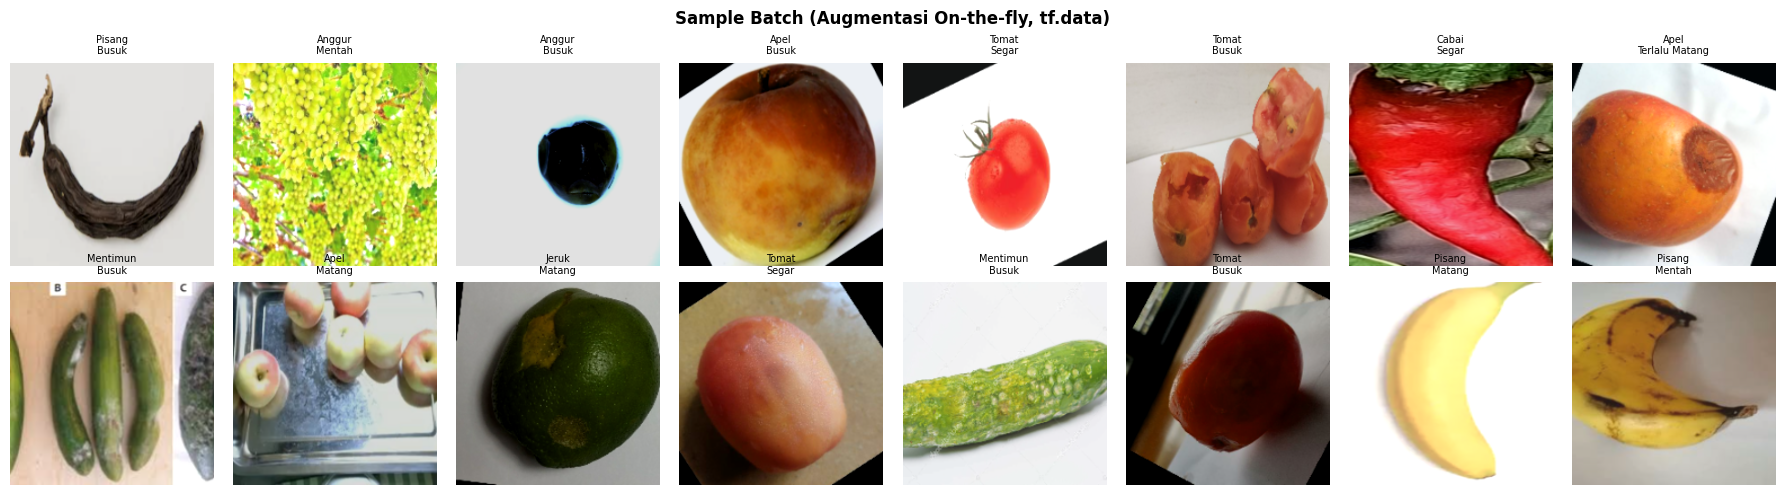

In [ ]:
# Visualisasi sample batch setelah augmentasi (dari tf.data)
sample_imgs, sample_labels = next(iter(train_ds))
fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_imgs[i].numpy())
    parts = CLASS_NAMES[sample_labels[i].numpy()].split('||')
    ax.set_title(f'{parts[0]}\n{parts[2]}', fontsize=7)
    ax.axis('off')
plt.suptitle('Sample Batch (Augmentasi On-the-fly, tf.data)', fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Bangun Model MobileNetV2

```
Input (224×224×3)
    ↓
MobileNetV2 — FROZEN (ImageNet weights)
    ↓
GlobalAveragePooling2D
    ↓
Dropout(0.3)
    ↓
Dense(256, relu)
    ↓
Dropout(0.2)
    ↓
Dense(30, softmax)
```

**Kenapa 1 fase cukup?**  
- MobileNetV2 dilatih di ImageNet yang kaya gambar objek sehari-hari termasuk buah/sayur

In [ ]:
def build_model(num_classes, img_size=224):
    """
    MobileNetV2 feature extraction (base model frozen sepenuhnya).
    Hanya head classifier yang dilatih.
    """
    # Base model: MobileNetV2 pretrained ImageNet, tanpa top layer
    base = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False   # Freeze semua layer base model

    # Functional API
    inputs  = keras.Input(shape=(img_size, img_size, 3))
    x       = base(inputs, training=False)   # training=False penting agar BatchNorm tetap inference mode
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dropout(0.3)(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2_SayurBuah')
    return model, base


model, base_model = build_model(NUM_CLASSES, IMG_SIZE)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_SayurBuah"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         7,710 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,630 (9.89 MB)

 Trainable params: 335,646 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
trainable     = np.sum([np.prod(w.shape) for w in model.trainable_weights])
non_trainable = np.sum([np.prod(w.shape) for w in model.non_trainable_weights])
print(f"Parameter trainable     : {trainable:,}  (head classifier)")
print(f"Parameter non-trainable : {non_trainable:,}  (MobileNetV2 frozen)")
print(f"Total                   : {trainable + non_trainable:,}")
print(f"\nEfisiensi RAM: hanya {trainable/(trainable+non_trainable)*100:.1f}% parameter yang dihitung gradiennya")

Parameter trainable     : 335,646  (head classifier)
Parameter non-trainable : 2,257,984  (MobileNetV2 frozen)
Total                   : 2,593,630

Efisiensi RAM: hanya 12.9% parameter yang dihitung gradiennya


## 7. Training — Feature Extraction dengan Class Weight

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',   # sparse: label integer, tidak perlu to_categorical
    metrics=['accuracy']
)

os.makedirs('checkpoints', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'checkpoints/best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("=" * 60)
print("TRAINING — Feature Extraction (MobileNetV2 frozen)")
print(f"  Epochs     : {EPOCHS} (EarlyStopping patience=8)")
print(f"  LR         : {LR}")
print(f"  Batch      : {BATCH_SIZE}")
print(f"  ClassWeight: aktif (balanced)")
print(f"  Pipeline   : tf.data + prefetch (GPU tidak idle)")
print("=" * 60)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)


TRAINING — Feature Extraction (MobileNetV2 frozen)
  Epochs     : 50 (EarlyStopping patience=8)
  LR         : 0.001
  Batch      : 32
  ClassWeight: aktif (balanced)
  Pipeline   : tf.data + prefetch (GPU tidak idle)
Epoch 1/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.5416 - loss: 1.5915
Epoch 1: val_loss improved from None to 0.59300, saving model to checkpoints/best_model.keras

Epoch 1: finished saving model to checkpoints/best_model.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 161s 251ms/step - accuracy: 0.6730 - loss: 1.0836 - val_accuracy: 0.7951 - val_loss: 0.5930 - learning_rate: 0.0010
Epoch 2/50
542/543 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7928 - loss: 0.6437
Epoch 2: val_loss improved from 0.59300 to 0.46463, saving model to checkpoints/best_model.keras

Epoch 2: finished saving model to checkpoints/best_model.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 104s 191ms/step - accuracy: 0.8060 - loss: 0.5989 - val_accuracy: 0.8287 - val_loss: 0.4646 - learning_rate: 0.00

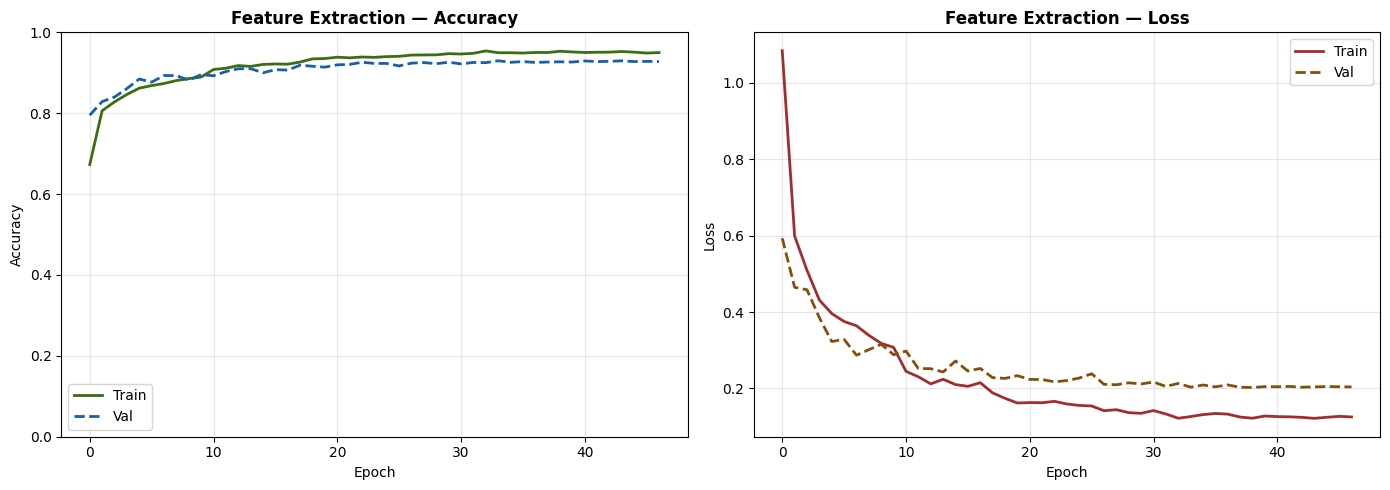

In [ ]:
def plot_history(history, title='Training'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='Train', color='#3b6d11', lw=2)
    ax1.plot(history.history['val_accuracy'], label='Val',   color='#185fa5', lw=2, ls='--')
    ax1.set_title(f'{title} — Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim(0, 1)

    ax2.plot(history.history['loss'],     label='Train', color='#a32d2d', lw=2)
    ax2.plot(history.history['val_loss'], label='Val',   color='#854f0b', lw=2, ls='--')
    ax2.set_title(f'{title} — Loss', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"history_{title.replace(' ','_').lower()}.png", dpi=120, bbox_inches='tight')
    plt.show()

plot_history(history, 'Feature Extraction')

## 8. Evaluasi Model

In [ ]:
# Load best checkpoint
model = keras.models.load_model('checkpoints/best_model.keras')

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

117/117 ━━━━━━━━━━━━━━━━━━━━ 26s 173ms/step - accuracy: 0.9193 - loss: 0.2659

Test Accuracy : 91.93%
Test Loss     : 0.2659


In [ ]:
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = y_test_idx

short_names = [f"{c.split('||')[0]}_{c.split('||')[2]}" for c in CLASS_NAMES]

print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=short_names))


117/117 ━━━━━━━━━━━━━━━━━━━━ 24s 160ms/step

CLASSIFICATION REPORT
                       precision    recall  f1-score   support

         Anggur_Busuk       0.95      0.84      0.89        91
        Anggur_Matang       0.52      0.65      0.58        17
        Anggur_Mentah       0.63      0.76      0.69        34
Anggur_Terlalu Matang       0.95      1.00      0.97        19
           Apel_Busuk       0.98      0.95      0.96       225
          Apel_Matang       0.98      0.90      0.94       225
          Apel_Mentah       0.62      0.89      0.73        37
  Apel_Terlalu Matang       0.86      0.99      0.92        70
          Cabai_Busuk       0.85      0.85      0.85        47
          Cabai_Segar       0.83      0.85      0.84        47
          Jeruk_Busuk       0.91      0.92      0.91       225
         Jeruk_Matang       0.95      0.90      0.93       225
         Jeruk_Mentah       0.97      0.94      0.95        31
 Jeruk_Terlalu Matang       0.69      0.75      0.

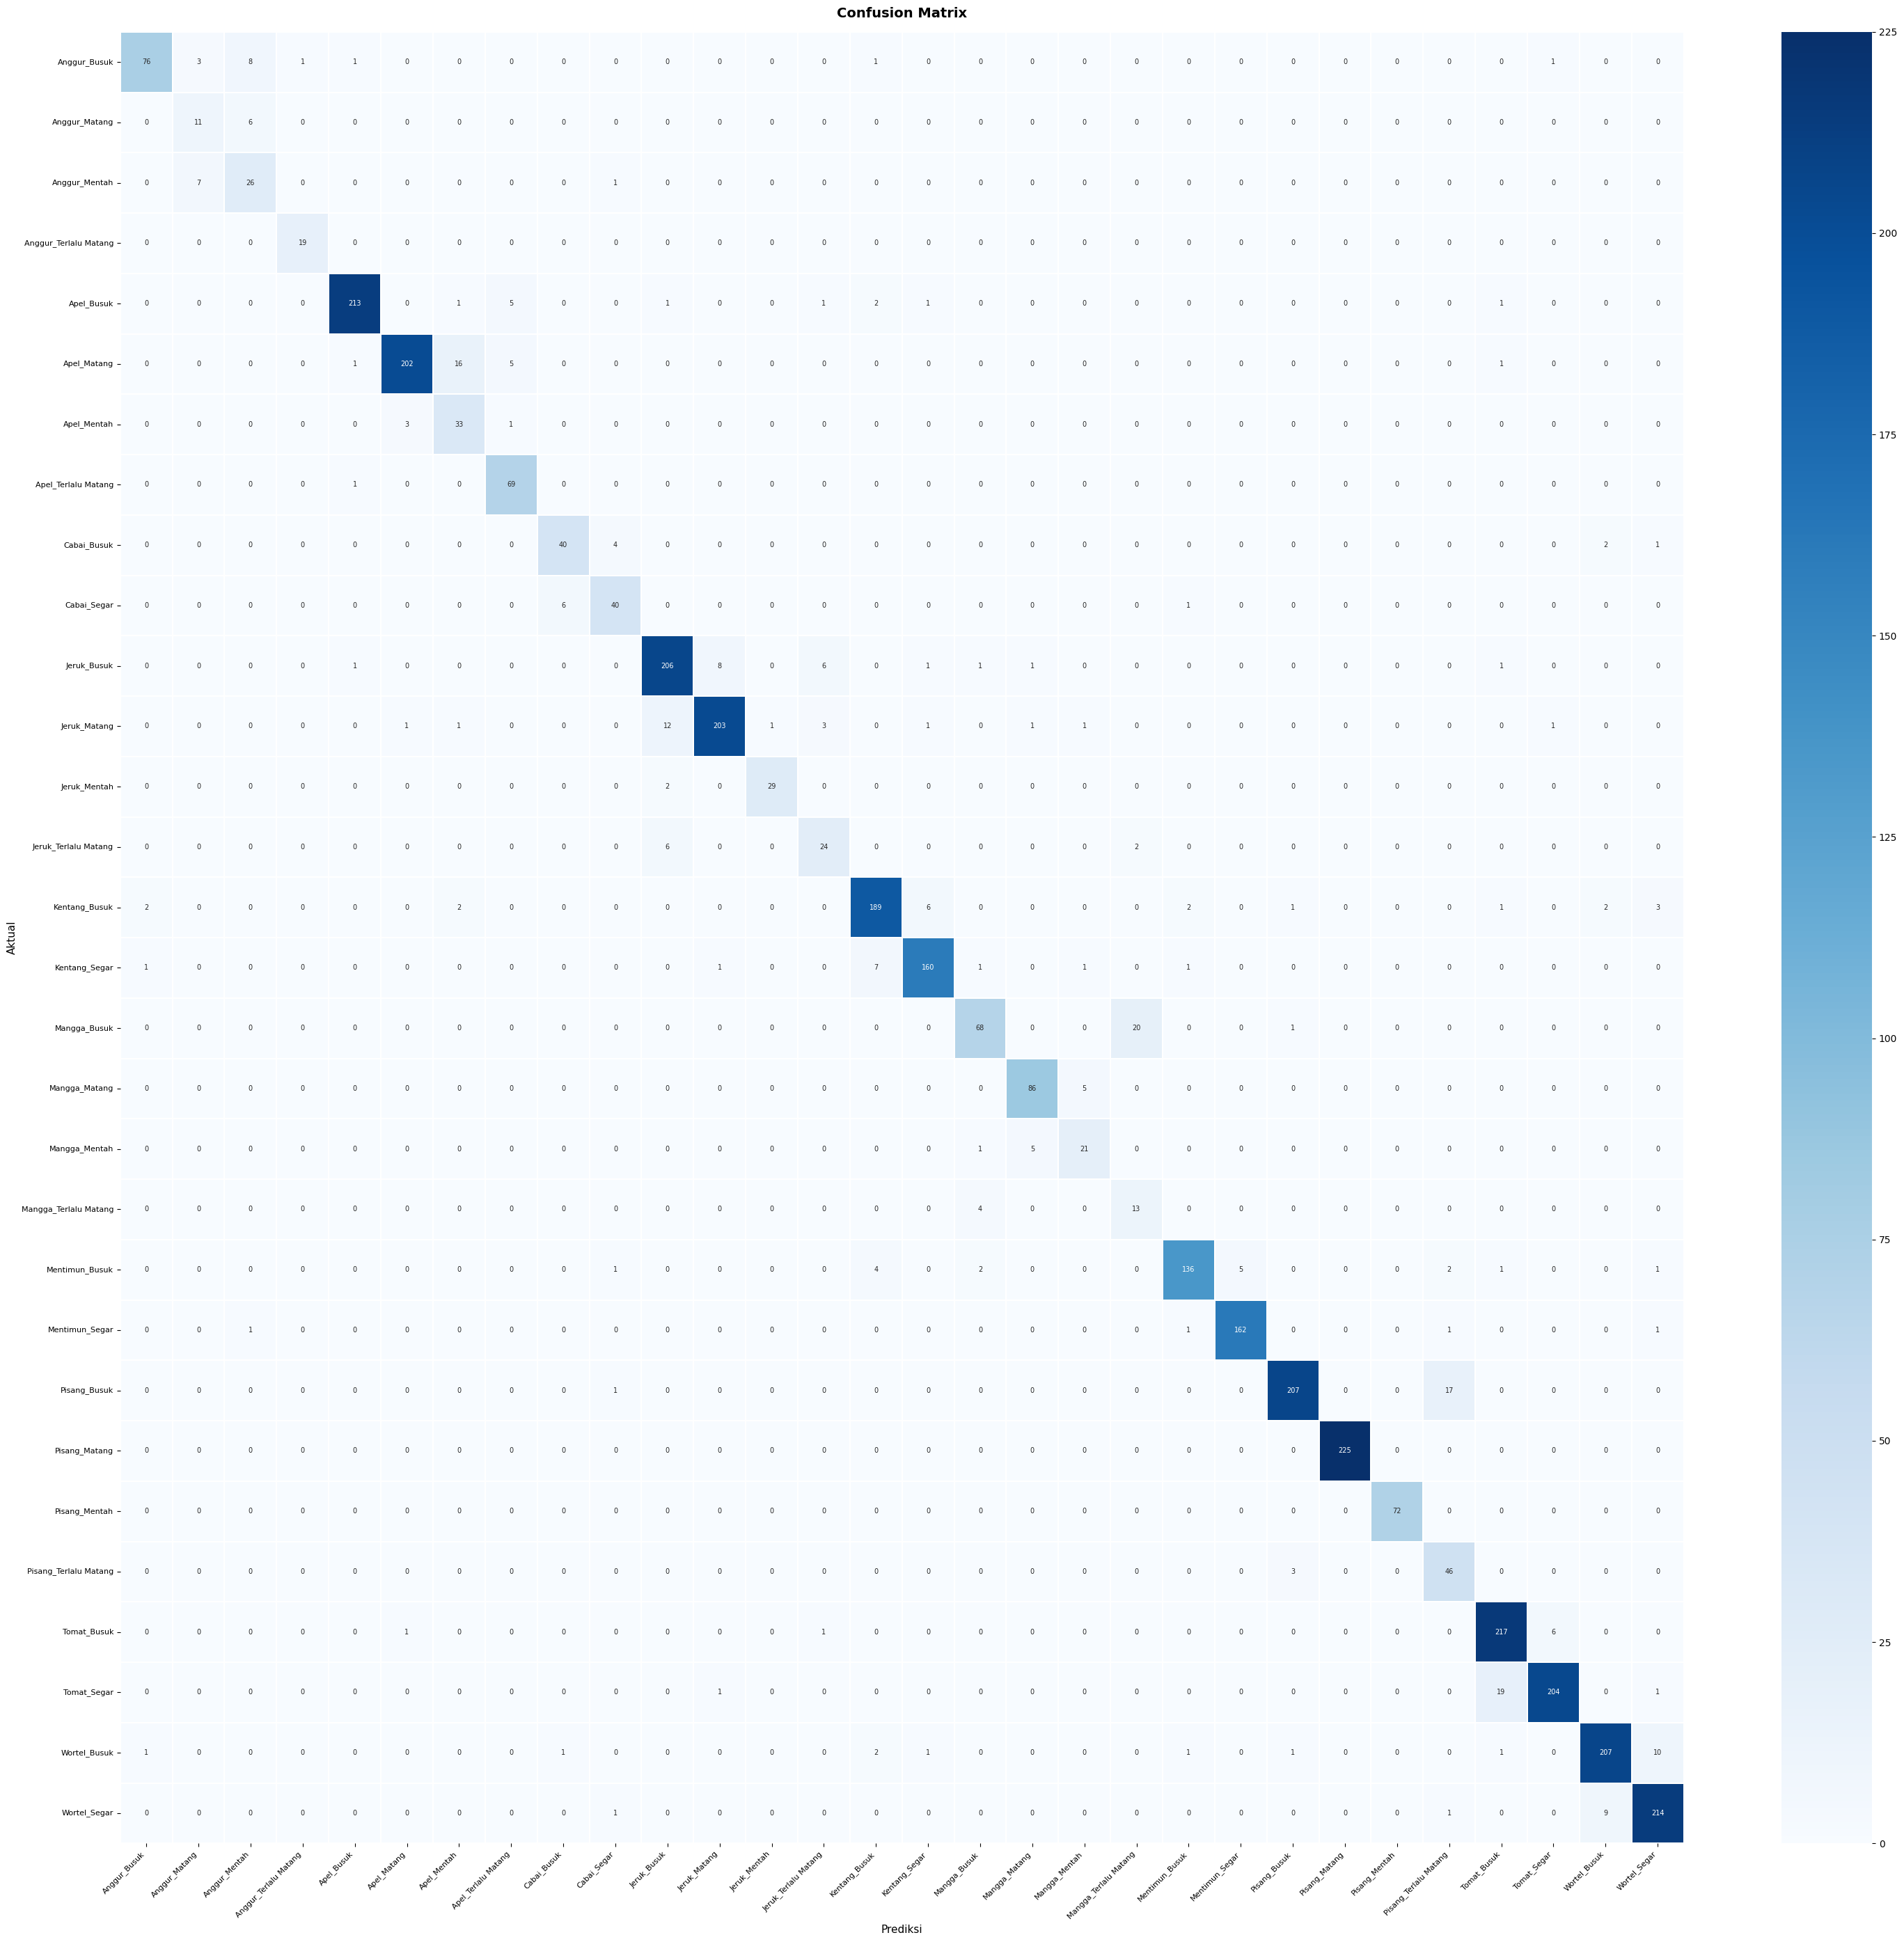

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(max(10, NUM_CLASSES), max(8, NUM_CLASSES - 2)))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=short_names, yticklabels=short_names,
    ax=ax, linewidths=0.3, annot_kws={'size': 7}
)
ax.set_xlabel('Prediksi', fontsize=11)
ax.set_ylabel('Aktual',   fontsize=11)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Item            Jenis   Kondisi           Accuracy      N
---------------------------------------------------------
Anggur          Buah    Busuk                83.5%     91
Anggur          Buah    Matang               64.7%     17
Anggur          Buah    Mentah               76.5%     34
Anggur          Buah    Terlalu Matang      100.0%     19
Apel            Buah    Busuk                94.7%    225
Apel            Buah    Matang               89.8%    225
Apel            Buah    Mentah               89.2%     37
Apel            Buah    Terlalu Matang       98.6%     70
Cabai           Sayur   Busuk                85.1%     47
Cabai           Sayur   Segar                85.1%     47
Jeruk           Buah    Busuk                91.6%    225
Jeruk           Buah    Matang               90.2%    225
Jeruk           Buah    Mentah               93.5%     31
Jeruk           Buah    Terlalu Matang       75.0%     32
Kentang         Sayur   Busuk                90.9%    208
Kentang       

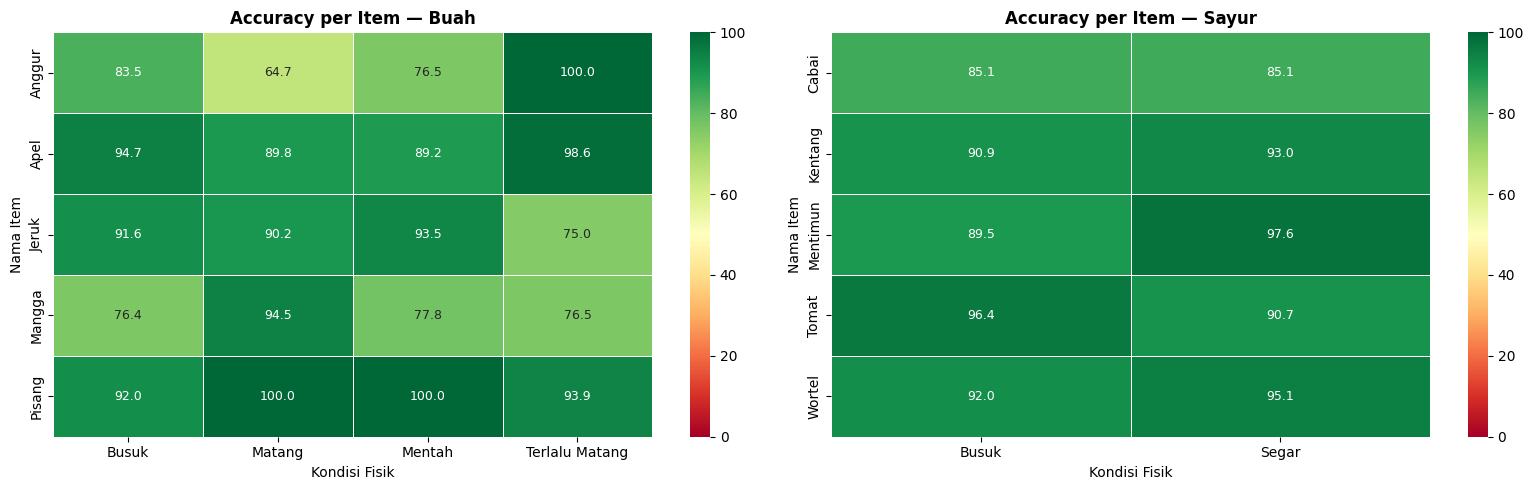

In [ ]:
# Accuracy per item & kondisi
print(f"{'Item':<15} {'Jenis':<7} {'Kondisi':<16} {'Accuracy':>9} {'N':>6}")
print("-" * 57)

rows = []
for cls_label in CLASS_NAMES:
    nama, jenis, kondisi = cls_label.split('||')
    idx  = label2idx[cls_label]
    mask = y_true == idx
    if mask.sum() == 0:
        continue
    acc = (y_pred[mask] == idx).mean()
    rows.append({'Item': nama, 'Jenis': jenis,
                 'Kondisi': kondisi, 'Accuracy': acc, 'N': mask.sum()})
    print(f"{nama:<15} {jenis:<7} {kondisi:<16} {acc*100:>8.1f}% {mask.sum():>6}")

df_acc = pd.DataFrame(rows)

# Heatmap accuracy
pivot_buah  = df_acc[df_acc['Jenis']=='Buah'].pivot(
    index='Item', columns='Kondisi', values='Accuracy')
pivot_sayur = df_acc[df_acc['Jenis']=='Sayur'].pivot(
    index='Item', columns='Kondisi', values='Accuracy')

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(df_acc['Item'].unique())//2)))
for ax, (pivot, title) in zip(axes, [
    (pivot_buah,  'Accuracy per Item — Buah'),
    (pivot_sayur, 'Accuracy per Item — Sayur')
]):
    if pivot is not None and not pivot.empty:
        sns.heatmap(pivot * 100, annot=True, fmt='.1f', cmap='RdYlGn',
                    vmin=0, vmax=100, ax=ax, linewidths=0.5, annot_kws={'size': 9})
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Kondisi Fisik')
        ax.set_ylabel('Nama Item')

plt.tight_layout()
plt.savefig('accuracy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Prediksi Gambar Baru + Out-of-Scope Detection

**Strategi mendeteksi gambar di luar cakupan (sepatu, hewan, dll.):**

1. **Confidence threshold**: Jika probabilitas prediksi tertinggi `max(softmax) < 0.60`, berarti model tidak cukup yakin → tolak input.
2. **Entropy check**: Jika nilai entropi `> 2.8`, menandakan distribusi probabilitas menyebar merata (model kebingungan) → tolak input.
   - **In-scope (Gambar valid):** Model sangat yakin pada 1 atau 2 kelas (distribusi menukik/peaked) → nilai entropi rendah.
   - **Out-of-scope (Gambar asing):** Model membagi probabilitas ke banyak kelas karena tidak ada yang cocok (distribusi merata) → nilai entropi tinggi (mendekati batas maksimal log(30) ≈ 3.40).

Jika salah satu atau kedua kondisi ini terpenuhi, gambar akan ditolak. Pendekatan ini *tidak 100% sempurna* (karena arsitektur dasar model kadang bisa mengalami *overconfidence* pada gambar asing), namun jauh lebih praktis dan hemat memori dibandingkan harus melatih ulang model dengan tambahan ribuan "dataset negatif".

In [ ]:
def compute_entropy(probs):
    """Shannon entropy dari distribusi probabilitas softmax."""
    probs = np.clip(probs, 1e-9, 1.0)  # hindari log(0)
    return -np.sum(probs * np.log(probs))


def predict_image(img_path, model,
                  class_names=CLASS_NAMES,
                  img_size=IMG_SIZE,
                  confidence_threshold=CONFIDENCE_THRESHOLD,
                  entropy_threshold=ENTROPY_THRESHOLD,
                  top_k=5):
    """
    Prediksi satu gambar dengan out-of-scope detection.

    Returns:
        dict dengan keys:
          - status         : 'OK' atau 'OUT_OF_SCOPE'
          - nama_item      : nama item (apple, cabe, dst.) — None jika out-of-scope
          - jenis_item     : 'Buah' atau 'Sayur'
          - kondisi_fisik  : kondisi
          - confidence     : persentase keyakinan
          - entropy        : nilai entropy softmax
          - reason         : penjelasan jika out-of-scope
    """

    img = load_img(img_path, target_size=(img_size, img_size))
    img_arr = img_to_array(img) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)

    probs      = model.predict(img_arr, verbose=0)[0]
    confidence = float(np.max(probs))
    entropy    = compute_entropy(probs)

    top_indices = probs.argsort()[::-1][:top_k]

    # Out-of-scope detection
    reasons = []
    if confidence < confidence_threshold:
        reasons.append(f"confidence rendah ({confidence*100:.1f}% < {confidence_threshold*100:.0f}%)")
    if entropy > entropy_threshold:
        reasons.append(f"entropy tinggi ({entropy:.2f} > {entropy_threshold:.2f})")

    KONDISI_COLOR = {
        'Mentah': '#aed6a0', 'Matang': '#3b6d11',
        'Terlalu Matang': '#854f0b', 'Busuk': '#a32d2d', 'Segar': '#3b6d11',
    }

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
    ax1.imshow(img); ax1.axis('off')

    bar_labels, bar_values, bar_colors = [], [], []
    for i in top_indices[::-1]:
        n, j, k = class_names[i].split('||')
        bar_labels.append(f"{n} — {k}")
        bar_values.append(probs[i] * 100)
        bar_colors.append(KONDISI_COLOR.get(k, '#333'))

    bars = ax2.barh(bar_labels, bar_values, color=bar_colors, alpha=0.85)
    ax2.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9)
    ax2.set_xlabel('Confidence (%)')
    ax2.set_title(f'Top-{top_k} Prediksi', fontweight='bold')
    ax2.set_xlim(0, 115)
    ax2.grid(axis='x', alpha=0.3)

    if reasons:
        # OUT OF SCOPE
        status = 'OUT_OF_SCOPE'
        reason_str = '; '.join(reasons)
        plt.suptitle(
            f"⚠️  TIDAK DIKENALI\n{reason_str}",
            fontsize=12, fontweight='bold', color='#cc0000', y=1.02
        )
        result = {
            'status'        : status,
            'nama_item'     : None,
            'jenis_item'    : None,
            'kondisi_fisik' : None,
            'confidence'    : f"{confidence*100:.2f}%",
            'entropy'       : f"{entropy:.3f}",
            'reason'        : reason_str
        }
    else:
        # IN SCOPE
        top_label = class_names[top_indices[0]]
        nama, jenis, kondisi = top_label.split('||')
        color = KONDISI_COLOR.get(kondisi, '#333')
        plt.suptitle(
            f"{nama.title()} ({jenis}) — {kondisi}  [{confidence*100:.1f}%]",
            fontsize=13, fontweight='bold', color=color, y=1.02
        )
        result = {
            'status'        : 'OK',
            'nama_item'     : nama,
            'jenis_item'    : jenis,
            'kondisi_fisik' : kondisi,
            'confidence'    : f"{confidence*100:.2f}%",
            'entropy'       : f"{entropy:.3f}",
            'reason'        : None
        }

    plt.tight_layout()
    plt.show()

    print("\n=== Hasil Prediksi ===")
    for k, v in result.items():
        if v is not None:
            print(f"  {k:<15}: {v}")
    return result

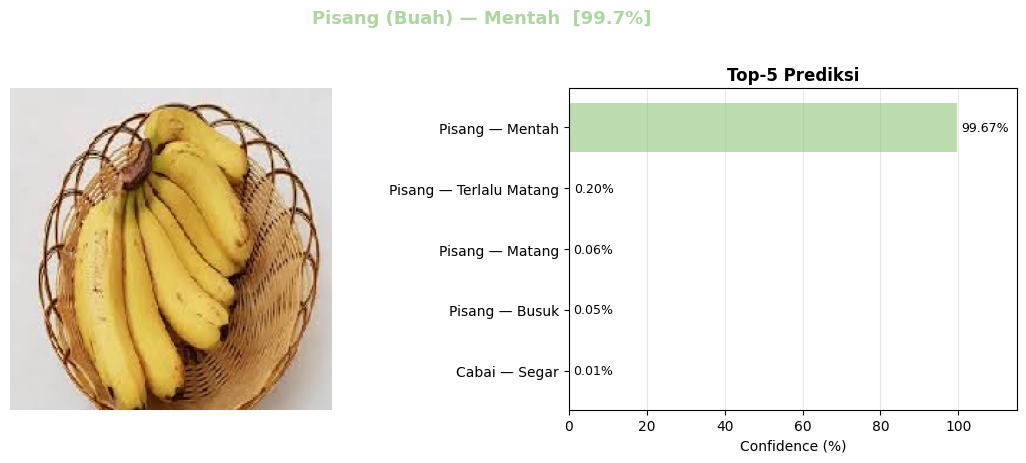


=== Hasil Prediksi ===
  status         : OK
  nama_item      : Pisang
  jenis_item     : Buah
  kondisi_fisik  : Mentah
  confidence     : 99.67%
  entropy        : 0.026


In [ ]:
# Contoh pemakaian
IMG_PATH = "test-image-in-scope.jpg"   # ganti dengan path gambar

if os.path.exists(IMG_PATH):
    result = predict_image(IMG_PATH, model)
else:
    print(f"File '{IMG_PATH}' tidak ditemukan.")

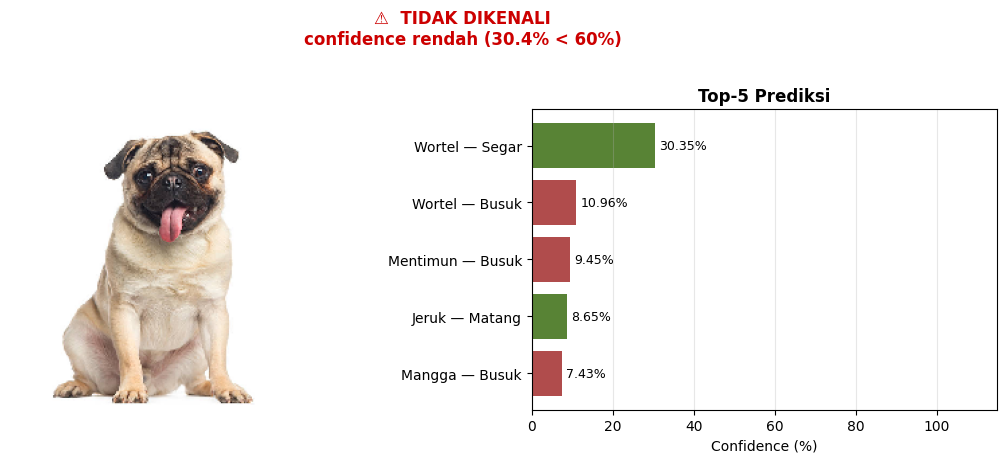


=== Hasil Prediksi ===
  status         : OUT_OF_SCOPE
  confidence     : 30.35%
  entropy        : 2.476
  reason         : confidence rendah (30.4% < 60%)


In [ ]:
# Contoh pemakaian
IMG_PATH = "test-image-out-of-scope.jpg"   # ganti dengan path gambar

if os.path.exists(IMG_PATH):
    result = predict_image(IMG_PATH, model)
else:
    print(f"File '{IMG_PATH}' tidak ditemukan.")

## 10. Evaluasi Out-of-Scope Threshold

Gunakan cell ini untuk menyetel threshold menggunakan data test yang ada.
Kita simulasikan "out-of-scope" dengan melihat distribusi entropy gambar in-scope,
lalu tentukan batas yang wajar.

Menghitung entropy pada test set...


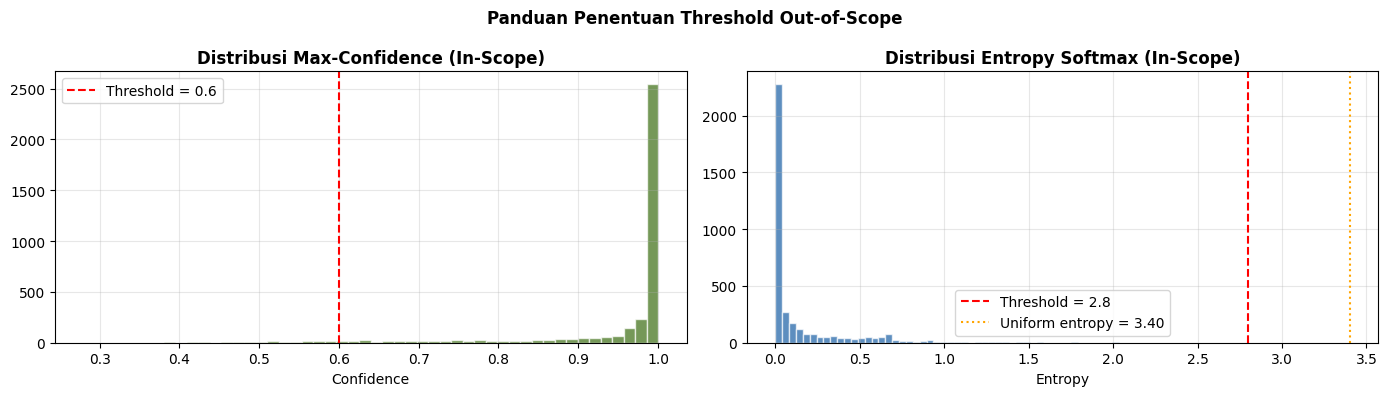


Statistik Confidence (in-scope test):
  Mean   : 0.948
  P5     : 0.648  (5% gambar in-scope di bawah ini)
  P1     : 0.504

Statistik Entropy (in-scope test):
  Mean   : 0.142
  P95    : 0.689
  P99    : 1.134

💡 Saran threshold:
   CONFIDENCE_THRESHOLD = 0.65  (P5 confidence)
   ENTROPY_THRESHOLD    = 0.69  (P95 entropy)


In [ ]:
# Distribusi confidence & entropy pada test set (in-scope)
print("Menghitung entropy pada test set...")

all_conf    = []
all_entropy = []

for batch_imgs, _ in test_ds:
    probs_batch = model.predict(batch_imgs, verbose=0)
    for p in probs_batch:
        all_conf.append(float(np.max(p)))
        all_entropy.append(compute_entropy(p))

all_conf    = np.array(all_conf[:len(y_test_idx)])
all_entropy = np.array(all_entropy[:len(y_test_idx)])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(all_conf, bins=50, color='#3b6d11', alpha=0.7, edgecolor='white')
axes[0].axvline(CONFIDENCE_THRESHOLD, color='red', ls='--',
                label=f'Threshold = {CONFIDENCE_THRESHOLD}')
axes[0].set_title('Distribusi Max-Confidence (In-Scope)', fontweight='bold')
axes[0].set_xlabel('Confidence'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(all_entropy, bins=50, color='#185fa5', alpha=0.7, edgecolor='white')
axes[1].axvline(ENTROPY_THRESHOLD, color='red', ls='--',
                label=f'Threshold = {ENTROPY_THRESHOLD}')
axes[1].axvline(np.log(NUM_CLASSES), color='orange', ls=':',
                label=f'Uniform entropy = {np.log(NUM_CLASSES):.2f}')
axes[1].set_title('Distribusi Entropy Softmax (In-Scope)', fontweight='bold')
axes[1].set_xlabel('Entropy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Panduan Penentuan Threshold Out-of-Scope', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nStatistik Confidence (in-scope test):")
print(f"  Mean   : {all_conf.mean():.3f}")
print(f"  P5     : {np.percentile(all_conf, 5):.3f}  (5% gambar in-scope di bawah ini)")
print(f"  P1     : {np.percentile(all_conf, 1):.3f}")
print(f"\nStatistik Entropy (in-scope test):")
print(f"  Mean   : {all_entropy.mean():.3f}")
print(f"  P95    : {np.percentile(all_entropy, 95):.3f}")
print(f"  P99    : {np.percentile(all_entropy, 99):.3f}")
print(f"\n💡 Saran threshold:")
print(f"   CONFIDENCE_THRESHOLD = {np.percentile(all_conf, 5):.2f}  (P5 confidence)")
print(f"   ENTROPY_THRESHOLD    = {np.percentile(all_entropy, 99):.2f}  (P99 entropy)")


## 11. Simpan & Export Model

In [ ]:
# Simpan model Keras
model.save('model.keras')
print("Saved: model.keras")

# Simpan metadata lengkap (termasuk threshold)
meta = {
    'class_names'          : CLASS_NAMES,
    'label2idx'            : label2idx,
    'num_classes'          : NUM_CLASSES,
    'img_size'             : IMG_SIZE,
    'label_format'         : 'nama_item||jenis_item||kondisi_fisik',
    'confidence_threshold' : CONFIDENCE_THRESHOLD,
    'entropy_threshold'    : ENTROPY_THRESHOLD,
    'entropy_uniform_30cls': float(np.log(NUM_CLASSES)),
    'jenis_item': {
        'Buah' : ['Mentah', 'Matang', 'Terlalu Matang', 'Busuk'],
        'Sayur': ['Segar', 'Busuk']
    }
}
with open('model_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print("Saved: model_metadata.json")

Saved: vision_model.keras
Saved: model_metadata.json


In [ ]:
# Export TFLite

saved_model_dir = 'saved_model'
os.makedirs(saved_model_dir, exist_ok=True)
os.makedirs('tflite', exist_ok=True)

try:
    model.export(saved_model_dir)
except AttributeError:
    model.save(saved_model_dir)
print(f"SavedModel tersimpan di: {saved_model_dir}/")

converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = 'tflite/model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(tflite_path) / (1024**2)
print(f"Saved: {tflite_path} ({size_mb:.1f} MB)")

# Simpan label.txt
with open('tflite/label.txt', 'w') as f:
    for cls in CLASS_NAMES:
        f.write(cls + '\n')
print("Saved: tflite/label.txt")
print("Siap deploy ke Android/iOS!")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 30), dtype=tf.float32, name=None)
Captures:
  132360290407376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132360290407952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132360290407568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132360290405840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132360290407760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132360290407184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132360290405072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132360290402960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132360290408336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132360290409296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132360290406608: 

In [ ]:
print("=" * 65)
print("RINGKASAN")
print("=" * 65)
print(f"  Model          : MobileNetV2 (pretrained ImageNet, frozen)")
print(f"  Input          : {IMG_SIZE}×{IMG_SIZE}×3")
print(f"  Total kelas    : {NUM_CLASSES}")
print(f"  Train          : {len(X_train):,}")
print(f"  Val            : {len(X_val):,}")
print(f"  Test           : {len(X_test):,}")
print(f"  Test Accuracy  : {test_acc*100:.2f}%")
print(f"  Test Loss      : {test_loss:.4f}")
print(f"  Class weight   : balanced (sklearn compute_class_weight)")
print(f"  Augmentasi     : on-the-fly (flip, crop, brightness, contrast, saturation)")
print(f"  Conf threshold : {CONFIDENCE_THRESHOLD} (out-of-scope rejection)")
print(f"  Entropy thresh : {ENTROPY_THRESHOLD} (uniform={np.log(NUM_CLASSES):.2f})")
print()
print("Label standar output:")
print("  Buah  → Mentah | Matang | Terlalu Matang | Busuk")
print("  Sayur → Segar  | Busuk")
print()
print("File output:")
print("  model.keras                          → model Keras")
print("  tflite/model.tflite                  → untuk mobile")
print("  tflite/label.txt                     → daftar kelas")
print("  model_metadata.json                  → metadata & threshold")
print("  confusion_matrix.png")
print("  accuracy_heatmap.png")
print("  threshold_analysis.png")

RINGKASAN
  Model          : MobileNetV2 (pretrained ImageNet, frozen)
  Input          : 224×224×3
  Total kelas    : 30
  Train          : 17,350
  Val            : 3,718
  Test           : 3,718
  Test Accuracy  : 91.93%
  Test Loss      : 0.2659
  Class weight   : balanced (sklearn compute_class_weight)
  Augmentasi     : on-the-fly (flip, crop, brightness, contrast, saturation)
  Conf threshold : 0.6 (out-of-scope rejection)
  Entropy thresh : 2.8 (uniform=3.40)

Label standar output:
  Buah  → Mentah | Matang | Terlalu Matang | Busuk
  Sayur → Segar  | Busuk

File output:
  vision_model.keras          → model Keras
  tflite/vision_model.tflite  → untuk mobile
  tflite/label.txt                     → daftar kelas
  model_metadata.json                  → metadata & threshold
  confusion_matrix.png
  accuracy_heatmap.png
  threshold_analysis.png


In [ ]:
# Mengompresi folder 'saved_model' menjadi 'saved_model.zip'
shutil.make_archive('saved_model', 'zip', 'saved_model')

print("Folder saved_model berhasil dikompresi menjadi zip!")

Folder saved_model berhasil dikompresi menjadi zip!


In [ ]:
# Mengompresi folder 'tflite' menjadi 'tflite.zip'
shutil.make_archive('tflite', 'zip', 'tflite')

print("Folder tflite berhasil dikompresi menjadi zip!")

Folder tflite berhasil dikompresi menjadi zip!
